In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.5.1+cu121
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import torch
import torch.nn as nn
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
    T5Config,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

c:\Users\chadp\OneDrive\Documents\NLP Project\Empathetic_Response_Generator\chatbot-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
train_df = pd.read_pickle('./dataset_emotions/train_emotions.pkl')
val_df = pd.read_pickle('./dataset_emotions/val_emotions.pkl')
test_df = pd.read_pickle('./dataset_emotions/test_emotions.pkl')

In [5]:
torch.cuda.empty_cache()

In [6]:
plutchik_emotions = ['neutral', 'joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
emotion2id = {emotion: idx for idx, emotion in enumerate(plutchik_emotions)}
id2emotion = {idx: emotion for emotion, idx in emotion2id.items()}

def extract_conversation_data(df):
    inputs = [x['input_text'] for x in df['conversation']]
    targets = [x['label'] for x in df['conversation']]
    input_emotions = [x['input_emotion'] for x in df['conversation']]
    label_emotions = [x['label_emotion'] for x in df['conversation']]
    return inputs, targets, input_emotions, label_emotions

train_inputs, train_targets, train_input_emotions, train_label_emotions = extract_conversation_data(train_df)
val_inputs, val_targets, val_input_emotions, val_label_emotions = extract_conversation_data(val_df)
test_inputs, test_targets, test_input_emotions, test_label_emotions = extract_conversation_data(test_df)

# Convert emotions to IDs (using neutral for unknown)
train_input_ids = [emotion2id.get(e, emotion2id['neutral']) for e in train_input_emotions]
val_input_ids = [emotion2id.get(e, emotion2id['neutral']) for e in val_input_emotions]
test_input_ids = [emotion2id.get(e, emotion2id['neutral']) for e in test_input_emotions]

In [7]:
print("Train inputs:", len(train_inputs))
print("Train input emotions:", len(train_input_ids))
print("Train targets:", len(train_targets))
print("Train target emotions:", len(train_label_emotions))

print("Validation inputs:", len(val_inputs))
print("Validation input emotions:", len(val_input_ids))

print("Test inputs:", len(test_inputs))
print("Test input emotions:", len(test_input_ids))

Train inputs: 36629
Train input emotions: 36629
Train targets: 36629
Train target emotions: 36629
Validation inputs: 5712
Validation input emotions: 5712
Test inputs: 5242
Test input emotions: 5242


In [8]:
# Print emotion to ID mapping
print("=== Emotion to ID Mapping ===")
for emotion, eid in emotion2id.items():
    print(f"{emotion}: {eid}")

# Check sample conversions
sample_emotions = train_input_emotions[:5]  # First 5 training examples
print("\n=== Sample Emotion Conversions ===")
for emotion in sample_emotions:
    print(f"'{emotion}' → ID: {emotion2id.get(emotion, 'UNKNOWN')}")

# Verify neutral fallback
unknown_emotion = "not_an_emotion"
print(f"\nUnknown emotion '{unknown_emotion}' → ID: {emotion2id.get(unknown_emotion, emotion2id['neutral'])}")

=== Emotion to ID Mapping ===
neutral: 0
joy: 1
trust: 2
fear: 3
surprise: 4
sadness: 5
disgust: 6
anger: 7
anticipation: 8

=== Sample Emotion Conversions ===
'joy' → ID: 1
'sadness' → ID: 5
'disgust' → ID: 6
'joy' → ID: 1
'joy' → ID: 1

Unknown emotion 'not_an_emotion' → ID: 0


In [9]:
def check_emotion_mapping(texts, emotions, emotion_ids, num_samples=5):
    print(f"\n{'Text':<50} | {'Emotion':<12} | {'ID':<3} | {'Verified'}")
    print("-"*80)
    for i in range(min(num_samples, len(texts))):
        # Get corresponding emotion name from ID for verification
        verified_emotion = id2emotion[emotion_ids[i]]
        print(f"{texts[i][:45]:<50} | {emotions[i]:<12} | {emotion_ids[i]:<3} | {verified_emotion == emotions[i]}")

In [10]:
print("=== Training Data Samples ===")
check_emotion_mapping(train_inputs, train_input_emotions, train_input_ids)

=== Training Data Samples ===

Text                                               | Emotion      | ID  | Verified
--------------------------------------------------------------------------------
I remember going to see the fireworks with my      | joy          | 1   | True
This was a best friend. I miss her.                | sadness      | 5   | True
We no longer talk.                                 | disgust      | 6   | True
My girlfriend got me a pet toad today!             | joy          | 1   | True
I do! I was so happy when I opened the box an      | joy          | 1   | True


In [ ]:
class T5WithEmotionEmbeddings(T5ForConditionalGeneration):
    def __init__(self, config):
        super().__init__(config)
        self.emotion_embedding = nn.Embedding(len(plutchik_emotions), config.d_model)
        
    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        decoder_input_ids=None,
        decoder_attention_mask=None,
        labels=None,
        emotion_ids=None,
        inputs_embeds=None,
        **kwargs
    ):
        # Handle cases where both input formats are None (during some generation steps)
        if input_ids is None and inputs_embeds is None:
            return super().forward(
                input_ids=input_ids,
                attention_mask=attention_mask,
                decoder_input_ids=decoder_input_ids,
                decoder_attention_mask=decoder_attention_mask,
                labels=labels,
                inputs_embeds=inputs_embeds,
                **kwargs
            )
        
        # Normal emotion-aware processing
        device = self.device
        batch_size = input_ids.shape[0] if input_ids is not None else inputs_embeds.shape[0]
        
        # Default to neutral if no emotion provided
        if emotion_ids is None:
            emotion_ids = torch.zeros(batch_size, dtype=torch.long, device=device)
        
        # Get input embeddings
        if inputs_embeds is None:
            inputs_embeds = self.shared(input_ids)
        
        # Add emotion information
        emotion_embeds = self.emotion_embedding(emotion_ids).unsqueeze(1)
        inputs_embeds = inputs_embeds + emotion_embeds.expand(-1, inputs_embeds.size(1), -1)
        
        return super().forward(
            input_ids=None,  # Using inputs_embeds instead
            attention_mask=attention_mask,
            decoder_input_ids=decoder_input_ids,
            decoder_attention_mask=decoder_attention_mask,
            labels=labels,
            inputs_embeds=inputs_embeds,
            **kwargs
        )

In [12]:
# class T5WithEmotionEmbeddings(T5ForConditionalGeneration):
#     def __init__(self, config):
#         super().__init__(config)
#         self.emotion_embedding = nn.Embedding(len(plutchik_emotions), config.d_model)

#     def forward(
#         self,
#         input_ids=None,
#         attention_mask=None,
#         decoder_input_ids=None,
#         decoder_attention_mask=None,
#         labels=None,
#         emotion_ids=None,
#         inputs_embeds=None,  # Add this parameter
#         **kwargs
#     ):
#         # Handle missing emotion IDs (default to neutral)
#         if emotion_ids is None:
#             emotion_ids = torch.zeros(input_ids.shape[0], dtype=torch.long, device=self.device)

#         # Get standard input embeddings
#         if inputs_embeds is None:
#             inputs_embeds = self.shared(input_ids)

#         # Add emotion information
#         emotion_embeds = self.emotion_embedding(emotion_ids).unsqueeze(1)  # [batch_size, 1, d_model]
#         emotion_embeds = emotion_embeds.expand(-1, inputs_embeds.size(1), -1)  # [batch_size, seq_len, d_model]
#         inputs_embeds = inputs_embeds + emotion_embeds

#         # Forward through encoder with modified embeddings
#         encoder_outputs = self.encoder(
#             inputs_embeds=inputs_embeds,
#             attention_mask=attention_mask,
#             **kwargs
#         )

#         # Normal decoder forward
#         return super().forward(
#             encoder_outputs=encoder_outputs,
#             attention_mask=attention_mask,
#             decoder_input_ids=decoder_input_ids,
#             decoder_attention_mask=decoder_attention_mask,
#             labels=labels,
#             **kwargs
#         )

In [13]:
# class T5WithEmotionEmbeddings(T5ForConditionalGeneration):
#     def __init__(self, config):
#         super().__init__(config)
#         self.emotion_embedding = nn.Embedding(len(plutchik_emotions), config.d_model)
        
#     def prepare_inputs_for_generation(self, input_ids, past=None, **kwargs):
#         # This ensures emotion_ids are passed during generation
#         inputs = super().prepare_inputs_for_generation(input_ids, past=past, **kwargs)
#         if 'emotion_ids' in kwargs:
#             inputs['emotion_ids'] = kwargs['emotion_ids']
#         return inputs

#     def forward(
#         self,
#         input_ids=None,
#         attention_mask=None,
#         decoder_input_ids=None,
#         decoder_attention_mask=None,
#         labels=None,
#         emotion_ids=None,
#         inputs_embeds=None,
#         **kwargs
#     ):
#         # Default to neutral emotion if not provided
#         if emotion_ids is None:
#             if input_ids is not None:
#                 emotion_ids = torch.zeros(input_ids.shape[0], dtype=torch.long, device=self.device)
#             else:
#                 emotion_ids = torch.zeros(inputs_embeds.shape[0], dtype=torch.long, device=self.device)

#         # Get standard embeddings
#         if inputs_embeds is None and input_ids is not None:
#             inputs_embeds = self.shared(input_ids)
        
#         # Add emotion embeddings if we have input embeddings
#         if inputs_embeds is not None:
#             emotion_embeds = self.emotion_embedding(emotion_ids).unsqueeze(1)
#             emotion_embeds = emotion_embeds.expand(-1, inputs_embeds.size(1), -1)
#             inputs_embeds = inputs_embeds + emotion_embeds

#         return super().forward(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             decoder_input_ids=decoder_input_ids,
#             decoder_attention_mask=decoder_attention_mask,
#             labels=labels,
#             inputs_embeds=inputs_embeds,
#             **kwargs
#         )

In [14]:
def create_dataset(inputs, targets, emotion_ids):
    return Dataset.from_dict({
        "input_text": inputs,
        "target_text": targets,
        "emotion_ids": emotion_ids
    })

raw_dataset = DatasetDict({
    "train": create_dataset(train_inputs, train_targets, train_input_ids),
    "validation": create_dataset(val_inputs, val_targets, val_input_ids),
    "test": create_dataset(test_inputs, test_targets, test_input_ids)
})


In [15]:
tokenizer = T5Tokenizer.from_pretrained("t5-small")

def tokenize_function(examples):
    model_inputs = tokenizer(
        examples["input_text"],
        text_target=examples["target_text"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )
    model_inputs["emotion_ids"] = examples["emotion_ids"]
    return model_inputs

tokenized_datasets = raw_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["input_text", "target_text"]
)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Map: 100%|██████████| 5242/5242 [00:00<00:00, 6530.33 examples/s]


In [16]:
class EmotionAwareTrainer(Seq2SeqTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):  # Added **kwargs
        emotion_ids = inputs.pop("emotion_ids")
        outputs = model(**inputs, emotion_ids=emotion_ids)
        return (outputs.loss, outputs) if return_outputs else outputs.loss

In [17]:
model = T5WithEmotionEmbeddings.from_pretrained("t5-small")

Some weights of T5WithEmotionEmbeddings were not initialized from the model checkpoint at t5-small and are newly initialized: ['emotion_embedding.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
print("\nVerification:")
sample = tokenized_datasets["train"][0]

# Convert lists to tensors for shape checking
input_ids_tensor = torch.tensor(sample["input_ids"])
emotion_id = sample["emotion_ids"]

print("Input IDs:", sample["input_ids"])
print("Input IDs shape (as tensor):", input_ids_tensor.shape)
print("Emotion ID:", emotion_id)
print("Corresponding emotion:", id2emotion[emotion_id])

# Additional verification
print("\nSample decoded:")
print("Input text:", tokenizer.decode(sample["input_ids"], skip_special_tokens=True))
print("Target text:", tokenizer.decode(sample["labels"], skip_special_tokens=True))


Verification:
Input IDs: [27, 1423, 352, 12, 217, 8, 23806, 28, 82, 200, 1565, 5, 94, 47, 8, 166, 97, 62, 664, 1869, 97, 2238, 544, 5, 1875, 132, 47, 3, 9, 418, 13, 151, 6, 62, 1800, 114, 8, 163, 151, 16, 8, 296, 5, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Input IDs shape (as tensor): torch.Size([128])
Emotion ID: 1
Corresponding emotion: joy

Sample decoded:
Input text: I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.
Target text: Was this a friend you were in love with, or just a best friend?


In [19]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./emotion_t5",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=20,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
)

trainer = EmotionAwareTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer
)

In [20]:
print("Starting training...")
trainer.train()

Starting training...


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch,Training Loss,Validation Loss
1,0.428800,0.411129
2,0.406300,0.401718
3,0.397600,0.396206
4,0.394500,0.392918
5,0.389900,0.390409
6,0.392300,0.388580
7,0.386200,0.387175
8,0.382200,0.385727
9,0.383800,0.384844
10,0.380500,0.383969


TrainOutput(global_step=45800, training_loss=0.3990104040620629, metrics={'train_runtime': 10772.5848, 'train_samples_per_second': 68.004, 'train_steps_per_second': 4.252, 'total_flos': 2.478717423058944e+16, 'train_loss': 0.3990104040620629, 'epoch': 20.0})

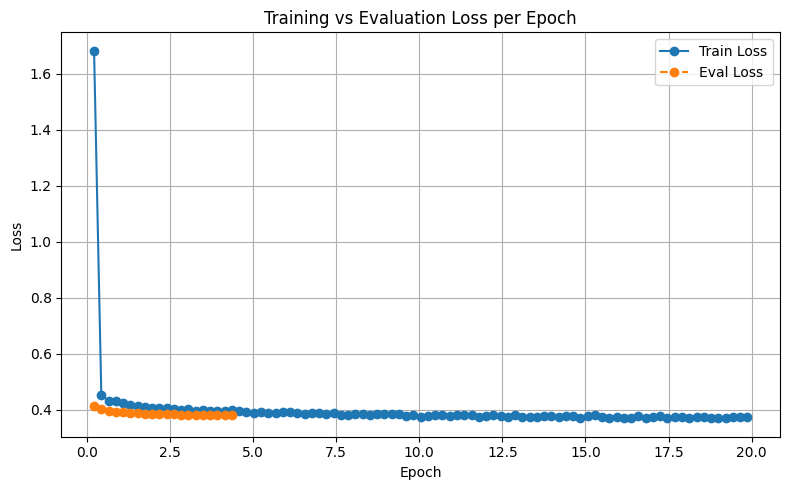

In [21]:
import matplotlib.pyplot as plt

# Extract logs from trainer state
logs = trainer.state.log_history

# Initialize lists for storing values
train_loss = []
eval_loss = []
epochs = []

# Separate and collect training and evaluation losses
for log in logs:
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])
        epochs.append(log['epoch'])
    if 'eval_loss' in log and 'epoch' in log:
        eval_loss.append(log['eval_loss'])

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs[:len(train_loss)], train_loss, label="Train Loss", marker='o')
plt.plot(epochs[:len(eval_loss)], eval_loss, label="Eval Loss", marker='o', linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
print(model)

T5WithEmotionEmbeddings(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Dropout

In [23]:
trainer._save("./t5-emotion-embed-finetuned/model")
tokenizer.save_pretrained("./t5-emotion-embed-finetuned/tokenizer")

('./t5-emotion-embed-finetuned/tokenizer\\tokenizer_config.json',
 './t5-emotion-embed-finetuned/tokenizer\\special_tokens_map.json',
 './t5-emotion-embed-finetuned/tokenizer\\spiece.model',
 './t5-emotion-embed-finetuned/tokenizer\\added_tokens.json')

In [24]:
results = trainer.evaluate()

In [25]:
results

{'eval_loss': 0.3806758522987366,
 'eval_runtime': 15.9877,
 'eval_samples_per_second': 357.274,
 'eval_steps_per_second': 22.33,
 'epoch': 20.0}

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def generate_response(input_text):
    # Ensure model is on the right device
    model.to(device)
    
    # Tokenize input
    inputs = tokenizer(input_text,
        return_tensors='pt',
        max_length=512,
        truncation=True  # <-- ensures no indexing error
    ).to(device)
    
    # Create emotion IDs - MUST match training format
    # During training you used: [emotion2id.get(e, emotion2id['neutral']) for e in emotions]
    # So we'll use neutral (0) as default
    emotion_ids = torch.tensor([0], dtype=torch.long, device=device)  # 0 = neutral
    
    # Generate response - MUST pass emotion_ids to match training
    outputs = model.generate(
        **inputs,
        emotion_ids=emotion_ids,  # This is critical
        max_length=50,
        do_sample=True,
        top_p=0.95,
        temperature=0.7
    )
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [59]:
print(generate_response("I lost my pet"))  


print(generate_response("We won the championship!"))


I'm sorry to hear that. Why did you lose your pet?
That is great! What did you win?


In [29]:
import pandas as pd

test_df = pd.read_pickle('./dataset_emotions/test_emotions.pkl')

test_df.shape

# test_df.head()
print(test_df['conversation'][0])

{'input_text': 'Yeah about 10 years ago I had a horrifying experience. It was 100% their fault but they hit the water barrels and survived. They had no injuries but they almost ran me off the road.', 'label': 'Did you suffer any injuries?', 'input_emotion': 'joy', 'label_emotion': 'anticipation'}


In [30]:
print(test_df.shape)

(5242, 1)


In [31]:
reference_sentences = []
generated_sentences = []
start = 2300
end = 2305
input_texts = []
for index, row in test_df[start:end].iterrows():
    input_text, label = row['conversation']['input_text'], row['conversation']['label']
    generated_sentences.append(generate_response(input_text))
    reference_sentences.append(label)
    input_texts.append(row['conversation']['input_text'])

# print(generated_sentences)
# print(reference_sentences)

for i, (x, y, z) in enumerate(zip(input_texts, reference_sentences, generated_sentences), start=start):
    print(f"Example {i}:")
    print(f"Input Prompt      : {x}")
    print(f"Reference Response: {y}")
    print(f"Generated Response: {z}")
    print("-" * 80)


Example 2300:
Input Prompt      : No, but he did end up puking all over the parking lot afterwards.
Reference Response: Hope you feel better
Generated Response: I hope he didn't get hurt too!
--------------------------------------------------------------------------------
Example 2301:
Input Prompt      : That is really cool. i bet it felt nice watching those
Reference Response: Uhm.. yeah, sure. I concur!
Generated Response: I think you should be able to enjoy it.
--------------------------------------------------------------------------------
Example 2302:
Input Prompt      : I envy people who can dance really well
Reference Response: Oh yeah, me too. They have such cool attitude
Generated Response: I am sure it will be a lot of fun.
--------------------------------------------------------------------------------
Example 2303:
Input Prompt      : I was stunned with fear to find a rattlesnake right where i was about to step into last week
Reference Response: holy cow! Thats terrifying

In [48]:
batch_size = 100
num_batches = int(len(test_df) / batch_size)

for batch in range(num_batches):
    start_index = batch * batch_size
    # start_index = batch * batch_size + 2600
    end_index = min(start_index + batch_size, len(test_df))
    batch_data = test_df[start_index:end_index]
    reference_sentences = []
    generated_sentences = []
    for index, row in batch_data.iterrows():
        input_text, label = row['conversation']['input_text'], row['conversation']['label']
        generated_sentences.append(generate_response(input_text))
        reference_sentences.append(label)
    df = pd.DataFrame({'reference_sentences': reference_sentences,
                       'generated_sentences': generated_sentences})
    df.to_pickle(f'./files/ref_gen_{start_index}.pkl')


In [49]:
import os
df_list = []

directory = './files/'

for filename in os.listdir(directory):
    if filename.endswith('.pkl'):
        filepath = os.path.join(directory, filename)
        df_list.append(pd.read_pickle(filepath))

merged_df = pd.concat(df_list, ignore_index=True)
merged_df.shape
merged_df.to_pickle('./files/ref_gen_master.pkl')


In [50]:
print(merged_df.shape)

(5200, 2)


In [51]:
# merged_df = pd.read_pickle('./files/ref_gen_1200.pkl')
merged_df.head()

,reference_sentences,generated_sentences
0,Did you suffer any injuries?,Oh no! That's really sad. I'm sorry to hear th...
1,Why did you feel guilty? People really shouldn...,I'm sorry you found him.
2,Wow that must have been a surprise for you,That's a really nice thing! What kind of choco...
3,you got a great husband,That's good. I'm glad he is able to do the sam...
4,"I know how you feel, it's terrible. I actually...",Oh no! How much is it?


In [52]:
import torch
import evaluate
import os
import pandas as pd

In [53]:
bleu = evaluate.load("bleu", module_type="metric")

bleu1 = bleu.compute(predictions=generated_sentences,
                     references=reference_sentences, max_order=1)
bleu2 = bleu.compute(predictions=generated_sentences,
                     references=reference_sentences, max_order=2)
bleu3 = bleu.compute(predictions=generated_sentences,
                     references=reference_sentences, max_order=3)
bleu4 = bleu.compute(predictions=generated_sentences,
                     references=reference_sentences, max_order=4)

print('BLEU 1', bleu1['bleu'])
print('BLEU 2', bleu2['bleu'])
print('BLEU 3', bleu3['bleu'])
print('BLEU 4', bleu4['bleu'])


print('Average BLEU:', (bleu1['bleu'] +
      bleu2['bleu'] + bleu3['bleu'] + bleu4['bleu'])/4)


BLEU 1 0.1509956890511106
BLEU 2 0.04790281091809629
BLEU 3 0.021323349433213956
BLEU 4 0.012320208411349908
Average BLEU: 0.058135514453442685


In [54]:
from bert_score import score

precision, recall, f1 = score(
    generated_sentences, reference_sentences, lang='en', verbose=False)

print(f"BERT score (F1): {f1.mean().item():.2f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT score (F1): 0.86


In [55]:
rouge = evaluate.load('rouge')
rouge_score = rouge.compute(
    predictions=generated_sentences, references=reference_sentences)
rouge_score


{'rouge1': np.float64(0.1411779721654755),
 'rouge2': np.float64(0.01653054298642534),
 'rougeL': np.float64(0.12909146130255003),
 'rougeLsum': np.float64(0.1294476906549279)}